Лабораторная работа 3
Построение первой модели машинного обучения  

Цель:
Освоить базовый процесс обучения модели и оценки её качества

Предметная область:
Анализ авиаперевозок и факторов, влияющих на задержки рейсов

Задача:
Построить модель, предсказывающую величину задержки рейса

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("finish.csv")
df.head()

,year,month,carrier,airport,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,...,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,delay_per_flight,total_delay
0,2022,7,9E,ABE,33.0,2.0,0.92,1.00,0.08,0.0,...,0.0,0.0,129.0,98.0,23.0,8.0,0.0,0.0,3.794118,129.0
1,2022,7,9E,ABY,78.0,25.0,11.80,0.72,5.01,0.0,...,0.0,0.0,1664.0,887.0,52.0,224.0,0.0,501.0,21.063291,1664.0
2,2022,7,9E,ACK,124.0,19.0,5.84,1.00,6.76,0.0,...,5.0,4.0,1523.0,388.0,35.0,511.0,0.0,589.0,12.184000,1523.0
3,2022,7,9E,AEX,67.0,10.0,1.32,1.00,2.40,1.0,...,0.0,1.0,657.0,103.0,82.0,93.0,25.0,354.0,9.661765,632.0
4,2022,7,9E,AGS,174.0,30.0,18.10,5.75,3.60,0.0,...,1.0,0.0,2462.0,1686.0,310.0,139.0,0.0,327.0,14.068571,2462.0


In [3]:
y = df['arr_delay']
X = df.drop(columns=['arr_delay'])

Обоснование выбора
В качестве целевой переменной выбрана arr_delay, так как она отражает итоговую задержку рейса и является ключевым показателем анализа

In [4]:
X = X.fillna(0)
y = y.fillna(0)
X = pd.get_dummies(X, drop_first=True)

Подготовка данных

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Данные разделены на:
80% обучающая выборка
20% тестовая выборка

random_state обеспечивает воспроизводимость

In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Обучение модели

In [7]:
y_pred = model.predict(X_test)

In [8]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.18031465706184022
MSE: 0.33316739546834884
RMSE: 0.5772065448938957
R2: 0.9999997969599917


Метрики качества

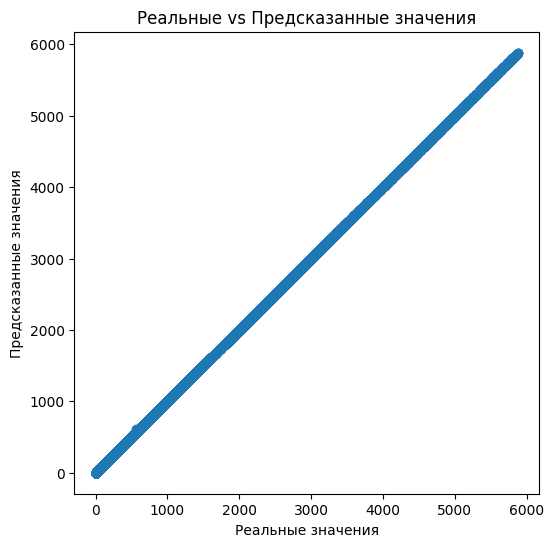

In [9]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Реальные значения")
plt.ylabel("Предсказанные значения")
plt.title("Реальные vs Предсказанные значения")
plt.show()

Визуализация результатов

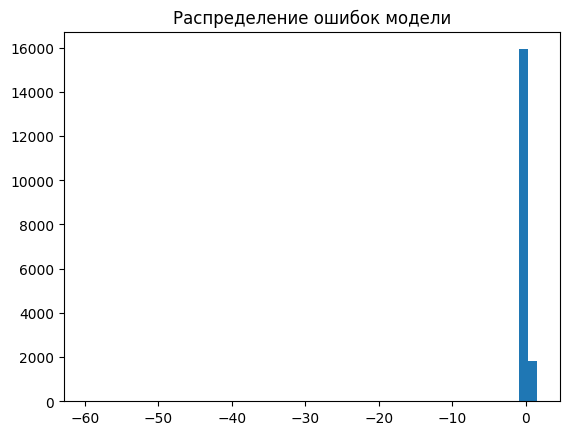

In [10]:
errors = y_test - y_pred
plt.hist(errors, bins=50)
plt.title("Распределение ошибок модели")
plt.show()

Ошибки модели

Анализ ошибок:
Ошибки распределены вокруг нуля
Присутствуют выбросы, влияющие на качество модели
Модель может недооценивать крупные задержки

Вывод:
Построена модель линейной регрессии для предсказания задержки рейсов
Данные были подготовлены и очищены
Модель показала базовый уровень точности
Метрики качества показывают наличие ошибок предсказания